<a href="https://colab.research.google.com/github/gez2code/dermamnist-hybrid-study/blob/main/First_DL_Baseline_Design.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
!rm -rf wandb

In [13]:
!pip install medmnist wandb

Random seed set to 42


Train shape: (7007, 28, 28, 3)
Illness cases in Train: 686 out of 7007
Class Weights: {0: np.float64(0.5542635658914729), 1: np.float64(5.107142857142857)}
Starting training with Data Augmentation...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 344ms/step - accuracy: 0.4813 - auc: 0.4932 - loss: 0.6936 - val_accuracy: 0.6481 - val_auc: 0.7862 - val_loss: 0.5172
Epoch 2/30
 1/54 ━━━━━━━━━━━━━━━━━━━━ 12s 229ms/step - accuracy: 0.5703 - auc: 0.6979 - loss: 0.6488

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5703 - auc: 0.6979 - loss: 0.6488 - val_accuracy: 0.6221 - val_auc: 0.7552 - val_loss: 0.5467
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 326ms/step - accuracy: 0.6239 - auc: 0.7537 - loss: 0.5478 - val_accuracy: 0.6879 - val_auc: 0.8267 - val_loss: 0.4786
Epoch 4/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6797 - auc: 0.7966 - loss: 0.4027 - val_accuracy: 0.7418 - val_auc: 0.8880 - val_loss: 0.3923
Epoch 5/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 318ms/step - accuracy: 0.6969 - auc: 0.8282 - loss: 0.5155 - val_accuracy: 0.6879 - val_auc: 0.8212 - val_loss: 0.5123
Epoch 6/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5938 - auc: 0.7338 - loss: 0.4932 - val_accuracy: 0.6859 - val_auc: 0.8217 - val_loss: 0.5095
Epoch 7/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 329ms/step - accuracy: 0.7302 - auc: 0.8512 - loss: 0.4404 - val_accuracy: 0.7547 - val_auc: 0.8833 - val_loss: 0.4566
Epoch 8/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step 

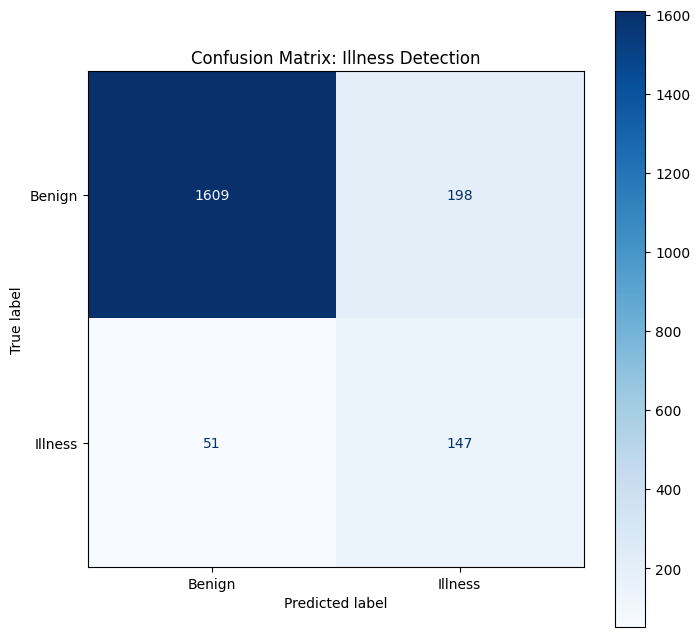

epoch/accuracy,▁▂▃▄▅▂▆▇▆▇▆▅▇▄▇▄▇█▇▆▇▇▇▇█▆█▇▇▇
epoch/auc,▁▃▅▅▆▄▆▇▆▇▇▆▇▄▇▄▇█▇▇██▇▆█▇█▇▇█
epoch/epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,██▆▃▅▅▄▁▄▅▄▄▄▅▄▄▃█▃▃▃▇▃▃▃▃▃▄▃▄
epoch/val_accuracy,▂▁▃▄▃▃▅▆▆▆▅▅▅█▄▅▆▅▆▆██▆▇▇▇▇▇██
epoch/val_auc,▂▁▄▆▃▃▆▇▆▇▆▅▅▇▄▅▇▅▇▇██▆▇▇█▇▇██
epoch/val_loss,▇█▆▄▇▇▆▄▄▃▄▅▅▃▇▅▃▆▃▃▁▁▄▃▃▂▃▄▂▁
epoch/accuracy,0.80469
epoch/auc,0.91559
epoch/epoch,29


In [15]:
# 1. INSTALL DEPENDENCIES
!pip install medmnist wandb -q

# 2. IMPORTS
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import medmnist
from medmnist import DermaMNIST
import wandb
from wandb.integration.keras import WandbMetricsLogger
import matplotlib.pyplot as plt
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ================= REPRODUCIBILITY BLOCK =================
SEED = 42

def set_seeds(seed=SEED):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
    np.random.seed(seed)

set_seeds()
print(f"Random seed set to {SEED}")
# =========================================================

# 3. SETUP W&B
wandb.login()

run = wandb.init(
    project="DermaMNIST_Project",
    name="Testrun_Baseline-CNN",
    config={
        "architecture": "Custom_CNN_Lecture13_Modified",
        "dataset": "DermaMNIST",
        "task": "Binary: Illness (1) vs Benign (0)",
        "batch_size": 128,
        "epochs": 30,
        "learning_rate": 0.001,
        "augmentation": True,
        "seed": SEED  # Log the seed so you remember it!
    }
)

# 4. DATA LOADING
print("Downloading and processing DermaMNIST...")
train_dataset = DermaMNIST(split='train', download=True, size=28)
val_dataset = DermaMNIST(split='val', download=True, size=28)
test_dataset = DermaMNIST(split='test', download=True, size=28)

x_train, y_train = train_dataset.imgs, train_dataset.labels
x_val, y_val = val_dataset.imgs, val_dataset.labels
x_test, y_test = test_dataset.imgs, test_dataset.labels

# Normalize
x_train = x_train.astype('float32') / 255.0
x_val = x_val.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 5. BINARY MAPPING (Broad: Cancer/Pre-Cancer vs Benign)
def to_binary(labels):
    # Class 0: akiec, 1: bcc, 6: mel -> 1 (Positive/Illness)
    # Others -> 0 (Benign)
    return np.isin(labels, [0, 1, 6]).astype(int)

y_train_bin = to_binary(y_train)
y_val_bin = to_binary(y_val)
y_test_bin = to_binary(y_test)

# One-hot encode
y_train_enc = tf.keras.utils.to_categorical(y_train_bin, 2)
y_val_enc = tf.keras.utils.to_categorical(y_val_bin, 2)
y_test_enc = tf.keras.utils.to_categorical(y_test_bin, 2)

print(f"Train shape: {x_train.shape}")
print(f"Illness cases in Train: {y_train_bin.sum()} out of {len(y_train_bin)}")

# 6. HANDLE IMBALANCE
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_bin),
    y=y_train_bin.flatten()
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Class Weights: {class_weight_dict}")

# 7. MODEL DESIGN
def build_model():
    model = models.Sequential()
    model.add(layers.Input(shape=(28, 28, 3)))

    # Block 1
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Block 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Block 3
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    # Head
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(2, activation='softmax'))

    return model

model = build_model()

# 8. EXPERIMENT SETUP
model.compile(
    optimizer=optimizers.Adam(learning_rate=wandb.config.learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# 9. TRAINING WITH AUGMENTATION
print("Starting training with Data Augmentation...")

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

# CHANGED: Added seed to flow() so augmentation is consistent across runs
history = model.fit(
    datagen.flow(x_train, y_train_enc, batch_size=wandb.config.batch_size, seed=SEED),
    steps_per_epoch=len(x_train) // wandb.config.batch_size,
    epochs=wandb.config.epochs,
    validation_data=(x_val, y_val_enc),
    class_weight=class_weight_dict,
    callbacks=[WandbMetricsLogger()]
)

# 10. EVALUATION & LOGGING
print("\n--- Evaluating on Test Set ---")
predictions = model.predict(x_test)
y_pred_classes = np.argmax(predictions, axis=1)
y_true_classes = np.argmax(y_test_enc, axis=1)

# Report (Updated labels for new task)
report = classification_report(
    y_true_classes,
    y_pred_classes,
    target_names=['Benign (0)', 'Illness/Cancer (1)']
)
print(report)

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Illness'])

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix: Illness Detection")
plt.show()

wandb.log({"confusion_matrix": wandb.Image(fig)})
wandb.finish()